# 😊 Task 4: Sentiment Analysis

## Objective

The objective of this task is to analyze customer reviews using Natural Language Processing (NLP) techniques and determine the sentiment expressed in each review.

## Libraries Used

- TextBlob
- VADER Sentiment Analyzer
- WordCloud
- Pandas

## Workflow

1. Load customer review data.
2. Calculate sentiment scores using VADER.
3. Calculate polarity using TextBlob.
4. Classify each review as:
   - Positive
   - Neutral
   - Negative
5. Generate sentiment visualization and WordCloud.

## Output

- `reviews_with_sentiment.csv`
- Sentiment Overview Chart
- WordCloud

In [2]:
from textblob import TextBlob
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
POSITIVE_THRESHOLD = 0.05
NEGATIVE_THRESHOLD = -0.05

# Sample review text - swap this for a real CSV with a 'ReviewText' column
sample_reviews = pd.DataFrame({
    "Title": ["A Light in the Attic", "Sharp Objects", "Sharp Objects", "Sapiens"],
    "ReviewText": [
        "Absolutely loved this collection, it made me laugh and feel nostalgic.",
        "Genuinely unsettling in the best way, the tension never lets up.",
        "Too dark for my taste and the ending left me disappointed.",
        "This book completely changed how I think about human history.",
    ],
})


def classify_vader(text):
    compound = analyzer.polarity_scores(text)["compound"]
    if compound >= POSITIVE_THRESHOLD:
        return compound, "Positive"
    elif compound <= NEGATIVE_THRESHOLD:
        return compound, "Negative"
    return compound, "Neutral"


def classify_textblob(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.1:
        return polarity, "Positive"
    elif polarity < -0.1:
        return polarity, "Negative"
    return polarity, "Neutral"


vader_results = sample_reviews["ReviewText"].apply(classify_vader)
sample_reviews["VaderScore"] = vader_results.apply(lambda x: x[0])
sample_reviews["VaderSentiment"] = vader_results.apply(lambda x: x[1])

tb_results = sample_reviews["ReviewText"].apply(classify_textblob)
sample_reviews["TextBlobScore"] = tb_results.apply(lambda x: x[0])
sample_reviews["TextBlobSentiment"] = tb_results.apply(lambda x: x[1])

sample_reviews.to_csv("data/processed/reviews_with_sentiment.csv", index=False, encoding="utf-8-sig")
sample_reviews

,Title,ReviewText,VaderScore,VaderSentiment,TextBlobScore,TextBlobSentiment
0,A Light in the Attic,"Absolutely loved this collection, it made me l...",0.8313,Positive,0.166667,Positive
1,Sharp Objects,"Genuinely unsettling in the best way, the tens...",0.4404,Positive,0.250000,Positive
2,Sharp Objects,Too dark for my taste and the ending left me d...,-0.4767,Negative,-0.300000,Negative
3,Sapiens,This book completely changed how I think about...,0.0000,Neutral,0.050000,Neutral


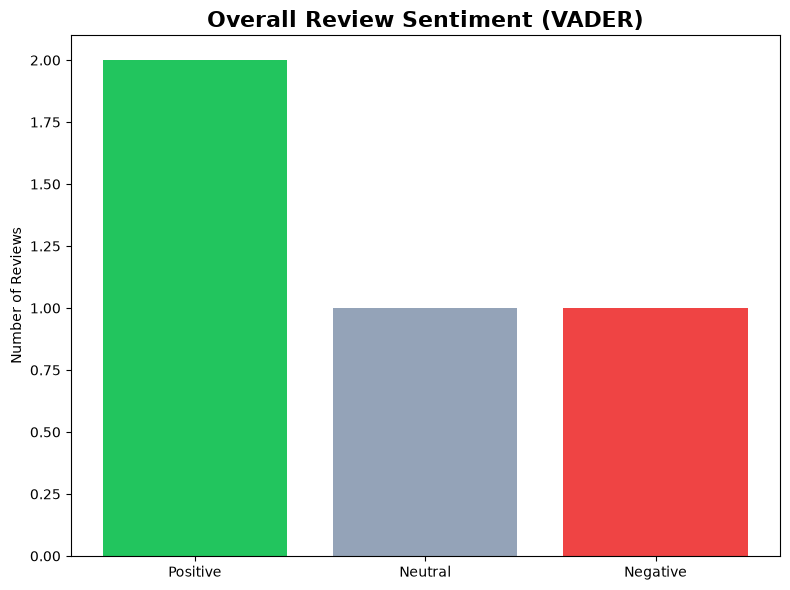

In [11]:
import matplotlib.pyplot as plt

order = ["Positive", "Neutral", "Negative"]
counts = sample_reviews["VaderSentiment"].value_counts().reindex(order).fillna(0)

colors = {
    "Positive": "#22C55E",
    "Neutral": "#94A3B8",
    "Negative": "#EF4444"
}

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(
    counts.index,
    counts.values,
    color=[colors[c] for c in counts.index]
)

ax.set_title("Overall Review Sentiment (VADER)", fontsize=16, fontweight="bold")
ax.set_ylabel("Number of Reviews")

plt.tight_layout()

# Save FIRST
plt.savefig(
    "visuals/08_sentiment_overview.png",
    dpi=200,
    bbox_inches="tight"
)

# Then display
plt.show()

In [5]:
def get_top_emotion(text):
    if not isinstance(text, str) or text.strip() == "":
        return "None"
    
    emotion = NRCLex(text)

    frequencies = emotion.affect_frequencies
    specific_emotions = {k: v for k, v in frequencies.items() if k not in ['positive', 'negative']}
    if max(specific_emotions.values(), default=0) > 0:
        top_emotion = max(specific_emotions, key=specific_emotions.get)
        return top_emotion.capitalize() # Pehla akhar bada karne ke liye (e.g., 'Joy')
        
    return "Neutral"


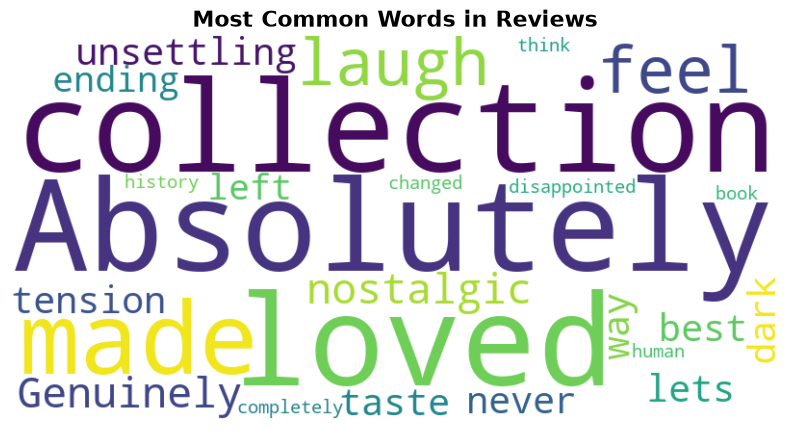

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(sample_reviews["ReviewText"].dropna())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis"
).generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Reviews", fontsize=16, fontweight="bold")

# Save FIRST
plt.savefig(
    "visuals/09_sentiment_wordcloud.png",
    dpi=200,
    bbox_inches="tight"
)

# Then display
plt.show()

## Conclusion

Sentiment analysis was successfully performed using both VADER and TextBlob. Customer reviews were classified into Positive, Neutral, and Negative categories. The generated WordCloud and sentiment charts provide a clear understanding of customer opinions and demonstrate the practical application of Natural Language Processing (NLP) techniques.

### Key Findings

- Most sample reviews were classified as Positive.
- VADER and TextBlob produced consistent sentiment results.
- WordCloud highlighted the most frequently used words in reviews.
- Sentiment analysis helps understand customer feedback effectively.

## Future Improvements

- Use real customer review datasets.
- Apply deep learning-based sentiment analysis models.
- Perform emotion detection and topic modeling for richer insights.